<a href="https://colab.research.google.com/github/ydv-prince/EDA/blob/main/EDA_1_Bike_Details_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Title: Bike Details Dataset**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [26]:
# name: Brand and model name of the bike
# selling_price: Listed selling price in INR
# year: Manufacturing year of the bike
# seller_type: Seller category, either "Individual" or "Dealer"
# owner: Ownership history, e.g., "1st owner", "2nd owner"
# km_driven: Total kilometers driven
# ex_showroom_price: Original showroom price in INR

In [27]:
original_url = 'https://drive.google.com/file/d/1iKy23bMtEQShF_weneRNnYrFmzvpPOI3/view'
url = 'https://drive.google.com/uc?id=1iKy23bMtEQShF_weneRNnYrFmzvpPOI3'

In [28]:
df = pd.read_csv(url)

In [29]:
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [31]:
#Q1. What is the range of selling prices in the dataset?

lowest = df['selling_price'].min()
highest = df['selling_price'].max()
range = highest - lowest
print(range)

# lowest = df['selling_price'].sort_values().iloc[0]
# highest = df['selling_price'].sort_values(ascending=False).iloc[0]

755000


In [32]:
#Q2. What is the median selling price for bikes in the dataset?

median = df['selling_price'].median()
print(median)

45000.0


In [33]:
#Q3. What is the most common seller type?

most_common_seller_type = df['seller_type'].value_counts().index[0]
print(most_common_seller_type)
# df['seller_type'].value_counts().head(1)

Individual


In [34]:
#Q4. How many bikes have driven more than 50,000 kilometers?

bikes_driven_more = (df['km_driven'] > 50000).sum()
print(bikes_driven_more)

170


In [35]:
#Q5. What is the average km_driven value for each ownership type?

avg_km_driven = df.groupby('owner')['km_driven'].mean()
for owner, km in enumerate(avg_km_driven):
  print(f"Owner: {owner} | Km: {km}")

Owner: 0 | Km: 32816.583333333336
Owner: 1 | Km: 39288.9918699187
Owner: 2 | Km: 33292.181818181816
Owner: 3 | Km: 311500.0


In [36]:
#Q6. What proportion of bikes are from the year 2015 or older?

proportion = (df['year'] < 2015).sum() / len(df)
print(proportion * 100)

47.219604147031106


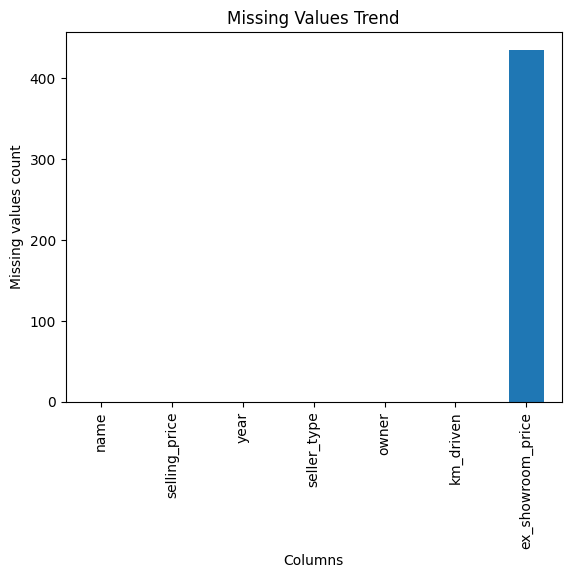

In [37]:
#Q7. What is the trend of missing values across the dataset?

missing_value = df.isna().sum()

missing_value.plot(kind = 'bar')
plt.title('Missing Values Trend')
plt.xlabel('Columns')
plt.ylabel('Missing values count')
plt.show()

In [38]:
#Q8. What is the highest ex_showroom_price recorded, and for which bike?

index = df['ex_showroom_price'].idxmax()
df.loc[index, ['name', 'ex_showroom_price']]

,134
name,Harley-Davidson Street Bob
ex_showroom_price,1278000.0


In [39]:
#Q9.  What is the total number of bikes listed by each seller type?

seller_type_count = df['seller_type'].value_counts()
seller_type_count

,count
seller_type,
Individual,1055
Dealer,6


In [40]:
df.owner.unique()

array(['1st owner', '2nd owner', '3rd owner', '4th owner'], dtype=object)

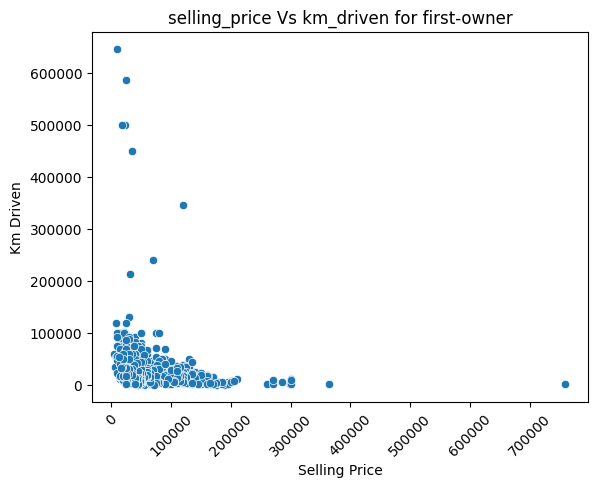

In [41]:
#Q10. What is the relationship between selling_price and km_driven for first-owner bikes?

first_owner = df[df['owner'] == '1st owner']
sns.scatterplot(x = 'selling_price', y = 'km_driven', data = first_owner, palette = 'dark')
plt.title('selling_price Vs km_driven for first-owner')
plt.xticks(rotation = 45)
plt.xlabel('Selling Price')
plt.ylabel('Km Driven')
plt.show()

In [42]:
#Q11. Identify and remove outliers in the km_driven column using the IQR method?

Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['km_driven'] < lower_bound) | (df['km_driven'] > upper_bound)]
outliers

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
91,Honda Activa [2000-2015],22989,2012,Individual,1st owner,500000,50267.0
93,Suzuki GS150R,30000,2010,Individual,1st owner,130000,70851.0
115,Hero Honda Passion Plus,7500,2004,Individual,1st owner,120000,NaN
135,Hero Honda CBZ extreme,20000,2007,Individual,1st owner,90000,NaN
154,Hero Xtreme Sports,22000,2014,Individual,1st owner,99000,78350.0
184,Honda CB Unicorn 160,75000,2015,Individual,1st owner,100000,79233.0
363,Hero Honda CD100SS,10000,1997,Individual,1st owner,646000,NaN
470,Honda Activa [2000-2015],23000,2009,Individual,1st owner,95000,50267.0
474,Hero Honda Passion PRO [2012],12000,2012,Individual,1st owner,90000,NaN
477,Honda Activa [2000-2015],25000,2009,Individual,1st owner,585659,50267.0


In [43]:
cleaned_df = df[(df['km_driven'] < lower_bound) | (df['km_driven'] > upper_bound)]
cleaned_df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
91,Honda Activa [2000-2015],22989,2012,Individual,1st owner,500000,50267.0
93,Suzuki GS150R,30000,2010,Individual,1st owner,130000,70851.0
115,Hero Honda Passion Plus,7500,2004,Individual,1st owner,120000,NaN
135,Hero Honda CBZ extreme,20000,2007,Individual,1st owner,90000,NaN
154,Hero Xtreme Sports,22000,2014,Individual,1st owner,99000,78350.0
184,Honda CB Unicorn 160,75000,2015,Individual,1st owner,100000,79233.0
363,Hero Honda CD100SS,10000,1997,Individual,1st owner,646000,NaN
470,Honda Activa [2000-2015],23000,2009,Individual,1st owner,95000,50267.0
474,Hero Honda Passion PRO [2012],12000,2012,Individual,1st owner,90000,NaN
477,Honda Activa [2000-2015],25000,2009,Individual,1st owner,585659,50267.0


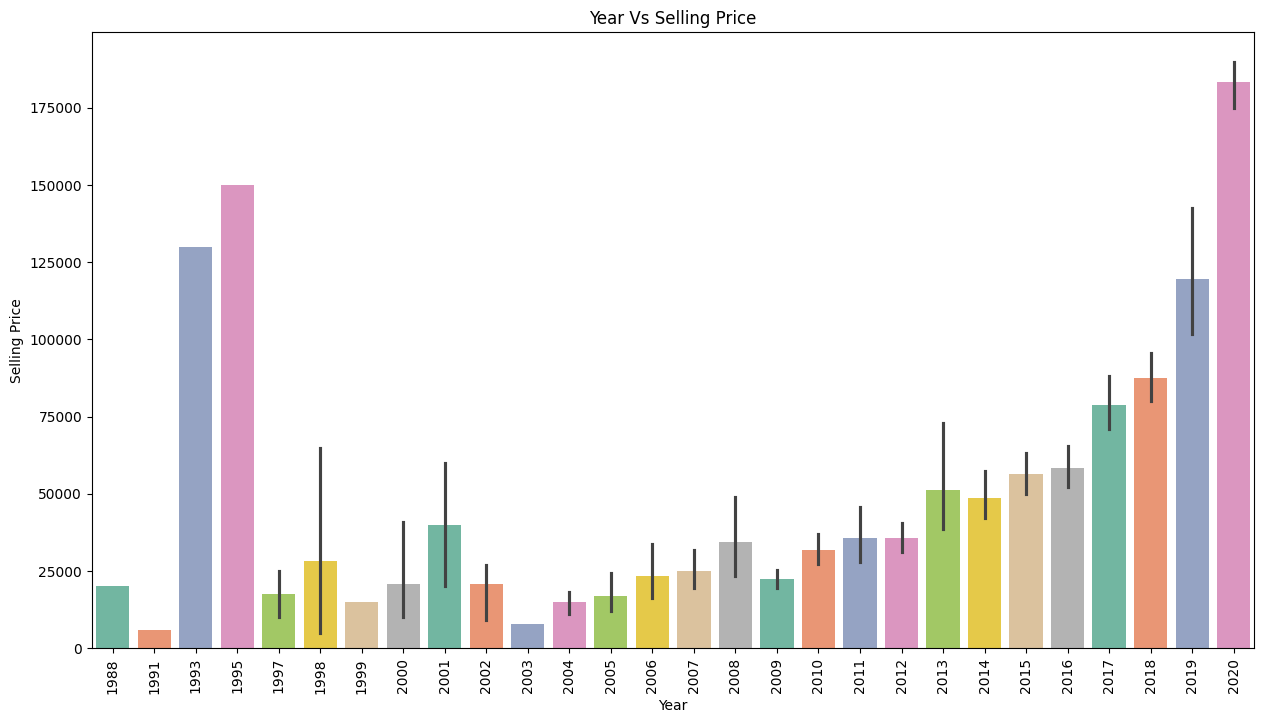

In [44]:
#Q12.  Perform a bivariate analysis to visualize the relationship between year and selling_price.

plt.figure(figsize = (15,8))
sns.barplot(x = 'year', y = 'selling_price', data = df, palette = 'Set2')
plt.title('Year Vs Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.xticks(rotation = 90)
# plt.yticks(rotation = 60)
plt.show()

In [45]:
#Q13. What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)?

current_year = 2025

# Calculate Bike Age
df['Bike_Age'] = current_year - df['year']

# Calculate Depreciation
df['Depreciation'] = df['ex_showroom_price'] - df['selling_price']

# Group by Age and compute averages
avg_depreciation = (df.groupby('Bike_Age')[['selling_price']].mean().reset_index())

avg_depreciation

,Bike_Age,selling_price
0,5,183333.333333
1,6,119689.511628
2,7,87660.374046
3,8,78894.736842
4,9,58469.018692
5,10,56500.000000
6,11,48668.131868
7,12,51136.986301
8,13,35748.400000
9,14,35655.721311


In [47]:
#Q14. Which bike names are priced significantly above the average price for their manufacturing year?

bikes = df[df['selling_price'] > 1.3 * df.groupby('year')['selling_price'].transform('mean')]['name'].unique()
for bike in bikes:
  print(bike)

Royal Enfield Classic 350
Royal Enfield Classic Gunmetal Grey
Royal Enfield Bullet 350 [2007-2011]
Yamaha YZF R3
Yamaha FZ25
Jawa Standard
Royal Enfield Thunderbird 350
Honda CBR-250R
Bajaj Dominar 400
KTM 390 Duke
Yamaha FZ16
Royal Enfield Electra 5 S
Royal Enfield Bullet 350
Royal Enfield Electra 4 S
Mahindra Mojo XT300
Royal Enfield Thunderbird 350X
Hero Honda Karizma ZMR [2010]
Royal Enfield Classic Desert Storm
UM Renegade Commando
Royal Enfield Continental GT 650
Harley-Davidson Street Bob
KTM 390 Duke ABS [2013-2016]
KTM 200 Duke
Royal Enfield Classic 500
KTM RC 390
Bajaj Pulsar 150
KTM RC 200
Honda CB Unicorn 160
Honda CB Unicorn 150
Royal Enfield Bullet 500
Bajaj Dominar 400 [2018]
Royal Enfield Interceptor 650
Bajaj Avenger Street 220
Royal Enfield Machismo
Hero Honda CBZ extreme
KTM 250 Duke
Kawasaki Ninja 650 [2018-2019]
Kawasaki Ninja 250R
Suzuki GSX S750
Yamaha Rx
Yamaha Fazer Dlx
Harley-Davidson Street 750
TVS Apache RR310
Yamaha YZF R15 V3
BMW G310GS
Royal Enfield Thund

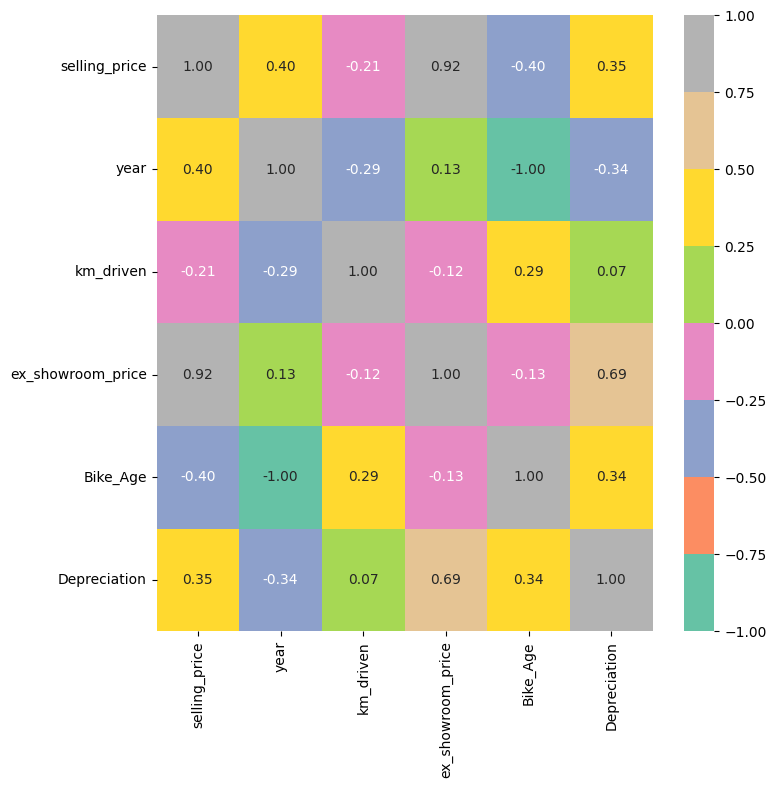

In [48]:
#Q15. Develop a correlation matrix for numeric columns and visualize it using a heatmap.

# num_features = [feature for feature in df.columns if df[feature].dtypes != 'object']
corr = df.corr(numeric_only= True)

plt.figure(figsize = (8,8))
sns.heatmap(corr, annot = True, cmap = 'Set2', fmt = '.2f')
plt.show()